In [13]:
import os, random, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D,
    Flatten, Dense, Dropout, LSTM, TimeDistributed, Input
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import joblib

# ── Config ──────────────────────────────────────────────────────────────────
DATASET_PATH   = r"C:\Users\USER\Documents\Sign-lang-recognization\asl_dataset"
IMG_H = IMG_W  = 64           # increase to 224 for higher accuracy
SEQ_LEN        = 5            # temporal frames per sequence
SEQS_PER_CLASS = 50
SEED           = 7
TEST_FRAC      = 0.20
VALID_FRAC     = 0.10
BATCH          = 32
EPOCHS         = 50

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow', tf.__version__)


TensorFlow 2.20.0


In [4]:
class_names = sorted([d for d in os.listdir(DATASET_PATH)
                       if os.path.isdir(os.path.join(DATASET_PATH, d))])

records = []
for cls in class_names:
    for fname in os.listdir(os.path.join(DATASET_PATH, cls)):
        records.append({'path': os.path.join(DATASET_PATH, cls, fname), 'label': cls})

df = pd.DataFrame(records).sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f'Total images : {len(df)}   Classes : {len(class_names)}')
print(df['label'].value_counts())


Total images : 2515   Classes : 36
label
s    70
r    70
0    70
2    70
e    70
u    70
i    70
7    70
y    70
z    70
9    70
g    70
x    70
j    70
4    70
k    70
h    70
n    70
3    70
a    70
c    70
p    70
1    70
o    70
f    70
q    70
m    70
6    70
l    70
v    70
5    70
8    70
d    70
w    70
b    70
t    65
Name: count, dtype: int64


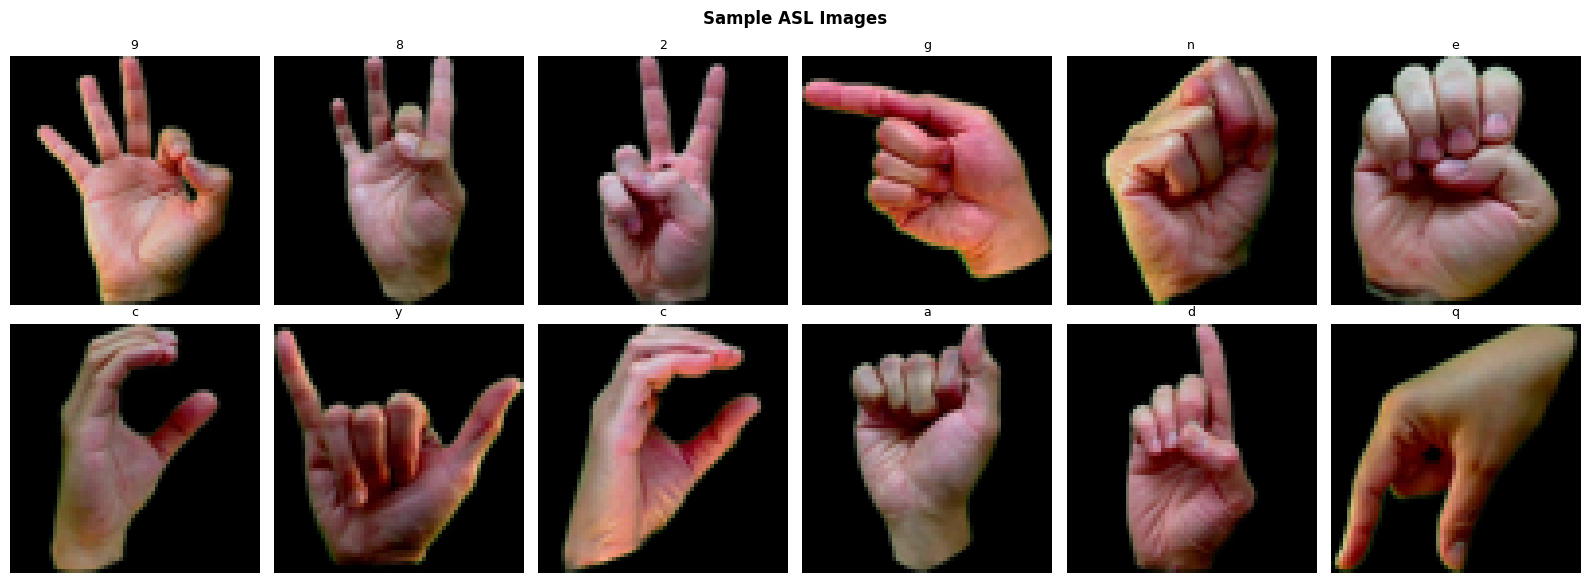

In [5]:
sample = df.sample(12, random_state=SEED)
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    ax.imshow(Image.open(row['path']).resize((IMG_W, IMG_H)))
    ax.set_title(row['label'], fontsize=9); ax.axis('off')
plt.suptitle('Sample ASL Images', fontweight='bold')
plt.tight_layout(); plt.show()


In [6]:
label_enc = LabelEncoder()
df['label_idx'] = label_enc.fit_transform(df['label'])
NUM_CLS = len(label_enc.classes_)
print('Classes:', NUM_CLS)

def load_norm(path, h=IMG_H, w=IMG_W):
    return img_to_array(load_img(path, target_size=(h, w))) / 255.0

def batch_load(paths, h=IMG_H, w=IMG_W):
    out = np.zeros((len(paths), h, w, 3), dtype=np.float32)
    for i, p in enumerate(paths):
        out[i] = load_norm(p, h, w)
    return out


Classes: 36


In [8]:
X_paths  = df['path'].values
Y_onehot = to_categorical(df['label_idx'].values, num_classes=NUM_CLS)

X_tr_p, X_tmp_p, Y_tr, Y_tmp = train_test_split(
    X_paths, Y_onehot, test_size=TEST_FRAC + VALID_FRAC, random_state=SEED)
X_val_p, X_te_p, Y_val, Y_te = train_test_split(
    X_tmp_p, Y_tmp,
    test_size=TEST_FRAC / (TEST_FRAC + VALID_FRAC), random_state=SEED)

print(f'Train {len(X_tr_p)} | Val {len(X_val_p)} | Test {len(X_te_p)}')
X_tr_arr  = batch_load(X_tr_p)
X_val_arr = batch_load(X_val_p)
X_te_arr  = batch_load(X_te_p)
print('Loaded. Train shape:', X_tr_arr.shape)



Train 1760 | Val 251 | Test 504
Loaded. Train shape: (1760, 64, 64, 3)


In [9]:
aug = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.15, height_shift_range=0.15,
    zoom_range=0.15, horizontal_flip=True,
    brightness_range=[0.8, 1.2], fill_mode='reflect')
aug.fit(X_tr_arr)


In [27]:
def build_cnn(h, w, n):
    m = Sequential(name='ASL_CNN')

    # Block 1
    m.add(Conv2D(32, (3,3), padding='same', input_shape=(h, w, 3)))
    m.add(BatchNormalization()); m.add(tf.keras.layers.Activation('relu'))
    m.add(MaxPooling2D(2))

    # Block 2
    m.add(Conv2D(64, (3,3), padding='same'))
    m.add(BatchNormalization()); m.add(tf.keras.layers.Activation('relu'))
    m.add(MaxPooling2D(2))

    # Block 3
    m.add(Conv2D(128, (3,3), padding='same'))
    m.add(BatchNormalization()); m.add(tf.keras.layers.Activation('relu'))
    m.add(MaxPooling2D(2))

    # Block 4 —
    m.add(Conv2D(256, (3,3), padding='same', activation='relu'))
    m.add(GlobalAveragePooling2D())

    # Dense head
    m.add(Dense(256)); m.add(BatchNormalization()); m.add(tf.keras.layers.Activation('relu'))
    m.add(Dropout(0.4))
    m.add(Dense(128, activation='relu'))
    m.add(Dropout(0.3))
    m.add(Dense(n, activation='softmax'))

    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),  # lower, stable LR
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    m.summary()
    return m

cnn_model = build_cnn(IMG_H, IMG_W, NUM_CLS)

cbs_cnn = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('cnn_best.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,   # patience was 3, too aggressive
                      min_lr=1e-6, verbose=1)
]

cnn_hist = cnn_model.fit(
    X_tr_arr, Y_tr,                        # pass arrays directly, NOT aug.flow
    validation_data=(X_val_arr, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=cbs_cnn,
    verbose=1
)

Model: "ASL_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 64, 64, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,8

 Total params: 493,668 (1.88 MB)

 Trainable params: 492,708 (1.88 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.1756 - loss: 2.9965 - val_accuracy: 0.0239 - val_loss: 3.5994 - learning_rate: 3.0000e-04
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.4551 - loss: 1.9780 - val_accuracy: 0.0239 - val_loss: 3.6503 - learning_rate: 3.0000e-04
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 0.6045 - loss: 1.3813 - val_accuracy: 0.0398 - val_loss: 3.7235 - learning_rate: 3.0000e-04
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.7142 - loss: 1.0281 - val_accuracy: 0.0359 - val_loss: 3.9612 - learning_rate: 3.0000e-04
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.7847 - loss: 0.7758 - val_accuracy: 0.0478 - val_loss: 4.3719 - learning_rate: 3.0000e-04
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.8299 - loss: 0.6381 
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.836

CNN  Test Accuracy: 95.24%   Loss: 0.1586
              precision    recall  f1-score   support

           0       0.91      0.56      0.69        18
           1       0.70      1.00      0.82         7
           2       0.96      1.00      0.98        23
           3       1.00      1.00      1.00        14
           4       1.00      0.95      0.97        19
           5       1.00      0.93      0.96        14
           6       0.81      0.81      0.81        16
           7       0.86      1.00      0.92        12
           8       1.00      0.90      0.95        10
           9       0.94      1.00      0.97        17
           a       1.00      1.00      1.00        15
           b       1.00      1.00      1.00        13
           c       1.00      1.00      1.00        15
           d       1.00      1.00      1.00        16
           e       1.00      1.00      1.00         9
           f       1.00      1.00      1.00        15
           g       1.00      1.00      

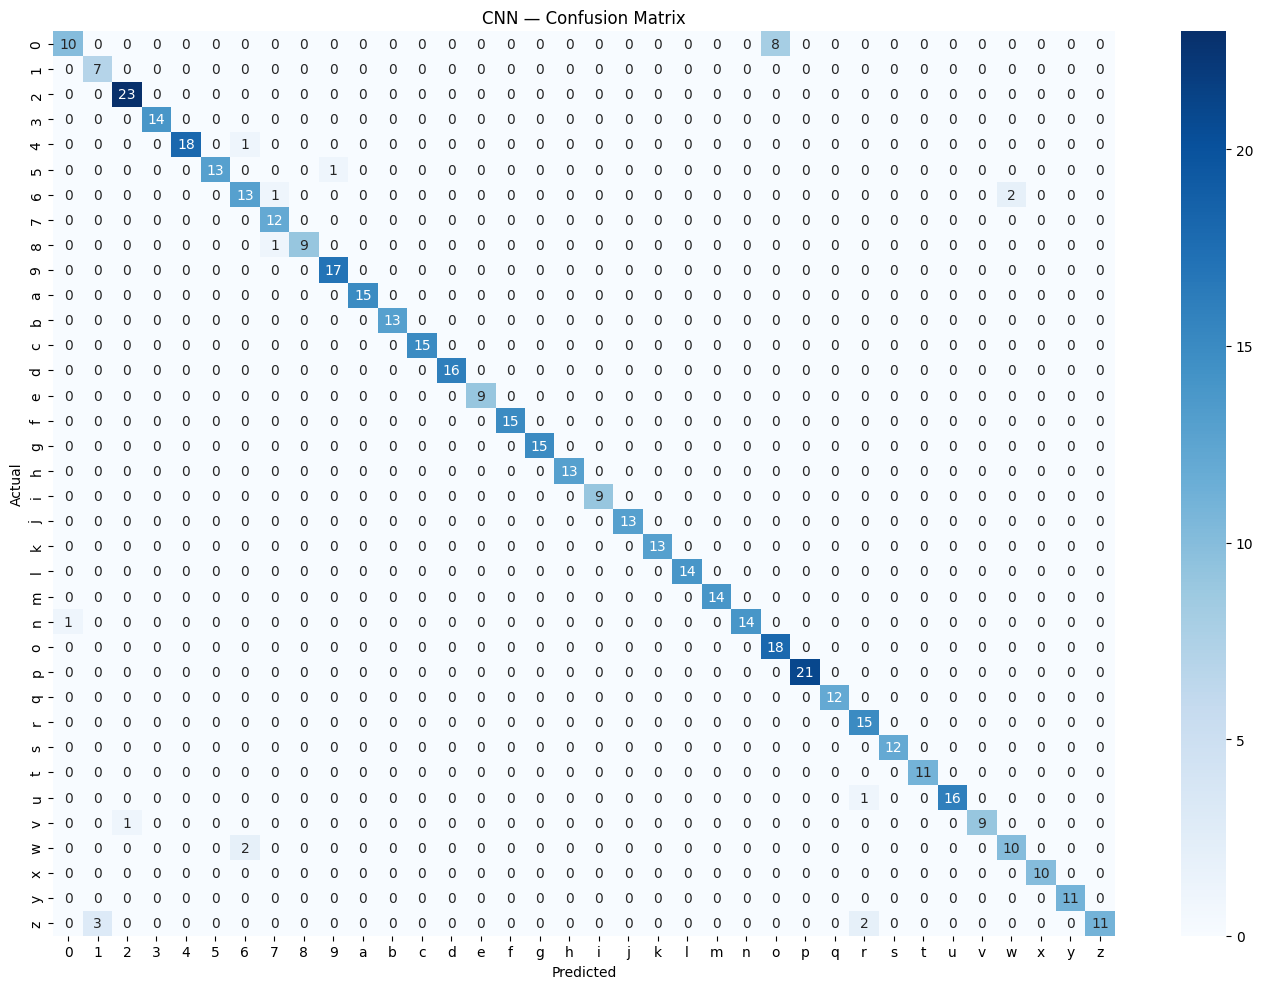

In [28]:
cnn_loss, cnn_acc = cnn_model.evaluate(X_te_arr, Y_te, verbose=0)
print(f'CNN  Test Accuracy: {cnn_acc*100:.2f}%   Loss: {cnn_loss:.4f}')

y_pred_cnn = np.argmax(cnn_model.predict(X_te_arr, verbose=0), axis=1)
y_true     = np.argmax(Y_te, axis=1)
print(classification_report(y_true, y_pred_cnn, target_names=label_enc.classes_))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(confusion_matrix(y_true, y_pred_cnn), annot=True, fmt='d',
            cmap='Blues', xticklabels=label_enc.classes_,
            yticklabels=label_enc.classes_, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('CNN — Confusion Matrix')
plt.tight_layout(); plt.show()


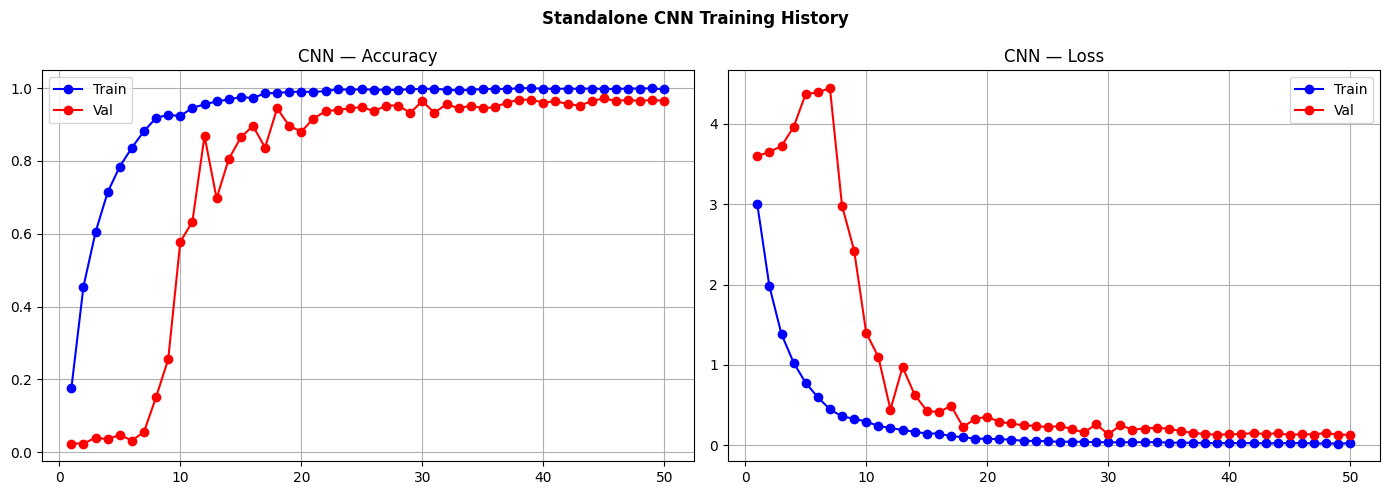

In [29]:
h = cnn_hist.history
ep = range(1, len(h['accuracy']) + 1)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.plot(ep, h['accuracy'], 'b-o', label='Train')
a1.plot(ep, h['val_accuracy'], 'r-o', label='Val')
a1.set_title('CNN — Accuracy'); a1.legend(); a1.grid(True)
a2.plot(ep, h['loss'], 'b-o', label='Train')
a2.plot(ep, h['val_loss'], 'r-o', label='Val')
a2.set_title('CNN — Loss'); a2.legend(); a2.grid(True)
plt.suptitle('Standalone CNN Training History', fontweight='bold')
plt.tight_layout(); plt.show()


In [17]:
cls_img_map = {cls: df[df['label'] == cls]['path'].tolist() for cls in class_names}

def make_sequences(cls_map, seq_len=SEQ_LEN, n=SEQS_PER_CLASS, h=IMG_H, w=IMG_W):
    seqs, lbls = [], []
    for lbl, paths in cls_map.items():
        if len(paths) < seq_len: continue
        for _ in range(n):
            chosen = random.choices(paths, k=seq_len)
            seqs.append([load_norm(p, h, w) for p in chosen])
            lbls.append(lbl)
    return np.array(seqs, dtype=np.float32), np.array(lbls)

print('Building sequences ...')
X_seq, Y_raw = make_sequences(cls_img_map)
print('Shape:', X_seq.shape)

seq_enc = LabelEncoder()
Y_enc   = seq_enc.fit_transform(Y_raw)

X_str, X_ste, Y_str, Y_ste = train_test_split(
    X_seq, Y_enc, test_size=TEST_FRAC, random_state=SEED)
print(f'Seq Train {len(X_str)} | Test {len(X_ste)}')


Building sequences ...
Shape: (1800, 5, 64, 64, 3)
Seq Train 1440 | Test 360


In [18]:
def build_frame_cnn(h, w):
    b = Sequential(name='FrameCNN', layers=[
        Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(h, w, 3)),
        BatchNormalization(), MaxPooling2D(2),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(), MaxPooling2D(2),
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(), MaxPooling2D(2),
        Conv2D(256, (3,3), padding='same', activation='relu'),
        BatchNormalization(), GlobalAveragePooling2D()
    ])
    b.summary()
    return b

frame_cnn = build_frame_cnn(IMG_H, IMG_W)

inp    = Input(shape=(SEQ_LEN, IMG_H, IMG_W, 3))
td     = TimeDistributed(frame_cnn)(inp)
lstm1  = LSTM(128, return_sequences=True, name='lstm_1')(td)
lstm2  = LSTM(64,  return_sequences=False, name='lstm_2')(lstm1)   # stacked
feat_mdl = Model(inputs=inp, outputs=lstm2, name='CNN_LSTM_Extractor')
feat_mdl.summary()


Model: "FrameCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64, 64, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 390,336 (1.49 MB)

 Trainable params: 389,376 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)

Model: "CNN_LSTM_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 5, 64, 64, 3)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 5, 256)              │         390,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 5, 128)              │         197,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 64)                  │          49,408 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 636,864 (2.43 MB)

 Trainable params: 635,904 (2.43 MB)

 Non-trainable params: 960 (3.75 KB)

In [19]:
print('Extracting features ...')
feat_tr = feat_mdl.predict(X_str, batch_size=16, verbose=1)
feat_te = feat_mdl.predict(X_ste, batch_size=16, verbose=1)
print('Feature dim:', feat_tr.shape[1])


Extracting features ...
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step
Feature dim: 64


CNN-LSTM-KNN  Accuracy: 98.61%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00         9
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00        11
           6       0.75      0.90      0.82        10
           7       1.00      1.00      1.00        16
           8       1.00      1.00      1.00        12
           9       1.00      1.00      1.00        11
           a       1.00      1.00      1.00         8
           b       1.00      1.00      1.00         8
           c       1.00      1.00      1.00        10
           d       1.00      1.00      1.00        15
           e       1.00      1.00      1.00        13
           f       1.00      1.00      1.00        10
           g       1.00      1.00      1.00       

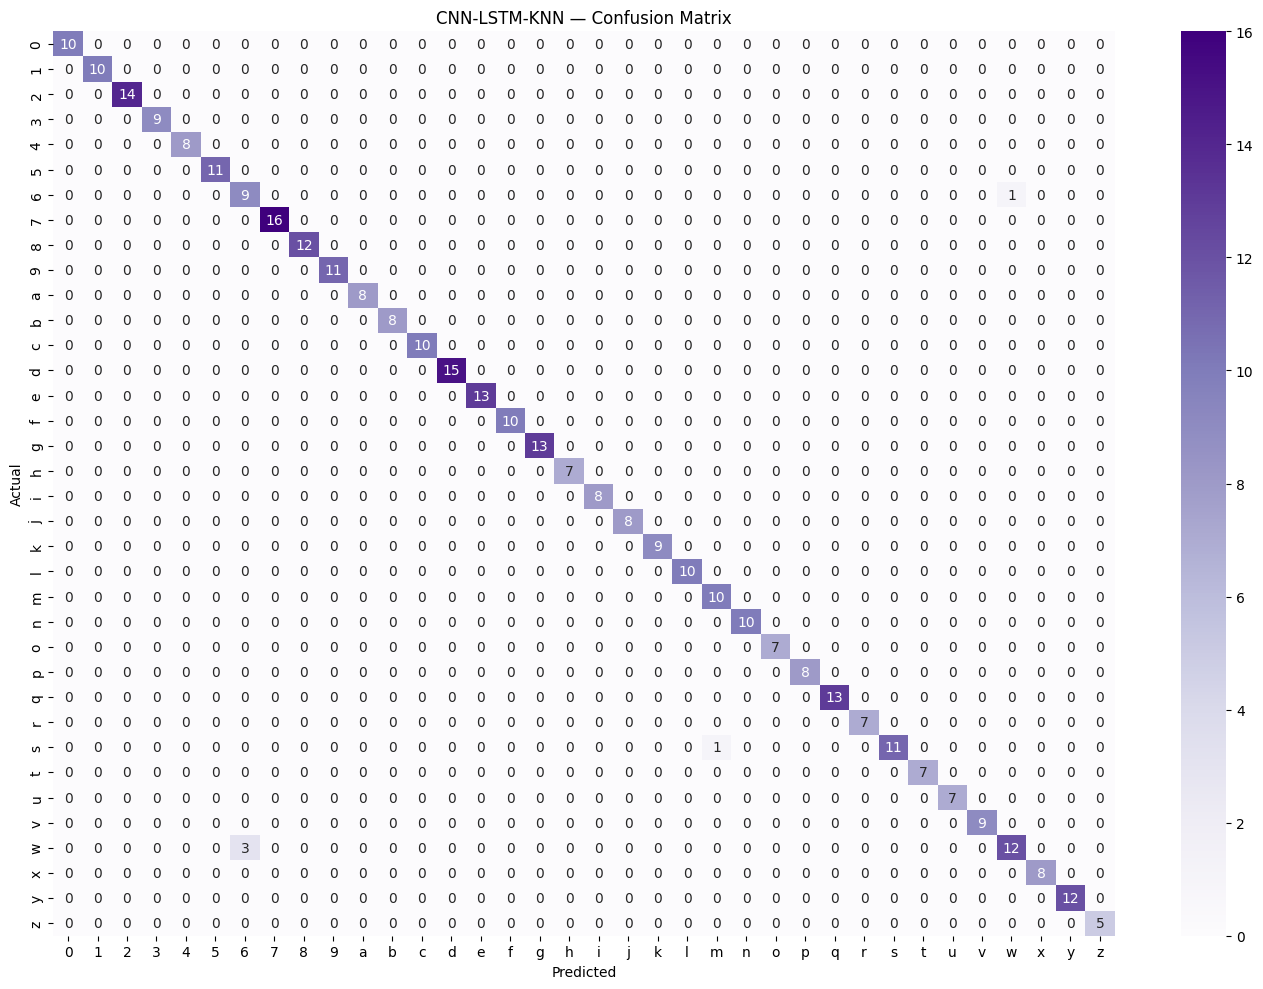

In [20]:
knn = KNeighborsClassifier(n_neighbors=5, metric='cosine', weights='distance')
knn.fit(feat_tr, Y_str)
knn_preds = knn.predict(feat_te)
knn_acc   = accuracy_score(Y_ste, knn_preds)
print(f'CNN-LSTM-KNN  Accuracy: {knn_acc*100:.2f}%')
print(classification_report(Y_ste, knn_preds, target_names=seq_enc.classes_))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(confusion_matrix(Y_ste, knn_preds), annot=True, fmt='d',
            cmap='Purples', xticklabels=seq_enc.classes_,
            yticklabels=seq_enc.classes_, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('CNN-LSTM-KNN — Confusion Matrix')
plt.tight_layout(); plt.show()


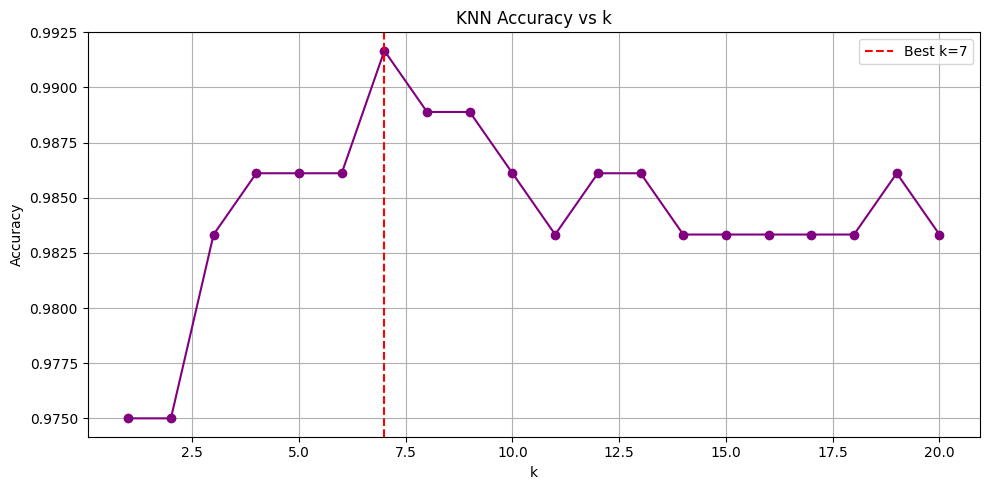

Best k=7  Accuracy=99.17%


In [21]:
k_accs = []
for k in range(1, 21):
    tmp = KNeighborsClassifier(n_neighbors=k, metric='cosine', weights='distance')
    tmp.fit(feat_tr, Y_str)
    k_accs.append(accuracy_score(Y_ste, tmp.predict(feat_te)))

best_k = np.argmax(k_accs) + 1
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), k_accs, 'o-', color='purple')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.title('KNN Accuracy vs k'); plt.xlabel('k'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
print(f'Best k={best_k}  Accuracy={max(k_accs)*100:.2f}%')


In [22]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    verbose=1)

print('Training Random Forest on CNN-LSTM embeddings ...')
rf.fit(feat_tr, Y_str)
rf_preds = rf.predict(feat_te)
rf_acc   = accuracy_score(Y_ste, rf_preds)
print(f'CNN-LSTM-RF  Accuracy: {rf_acc*100:.2f}%')
print(classification_report(Y_ste, rf_preds, target_names=seq_enc.classes_))


Training Random Forest on CNN-LSTM embeddings ...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    2.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.1s finished


CNN-LSTM-RF  Accuracy: 95.28%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       0.93      1.00      0.97        14
           3       1.00      1.00      1.00         9
           4       0.70      0.88      0.78         8
           5       0.91      0.91      0.91        11
           6       0.73      0.80      0.76        10
           7       1.00      0.94      0.97        16
           8       1.00      0.92      0.96        12
           9       1.00      1.00      1.00        11
           a       1.00      0.88      0.93         8
           b       1.00      1.00      1.00         8
           c       1.00      1.00      1.00        10
           d       1.00      1.00      1.00        15
           e       1.00      1.00      1.00        13
           f       1.00      1.00      1.00        10
           g       0.92      0.92      0.92        

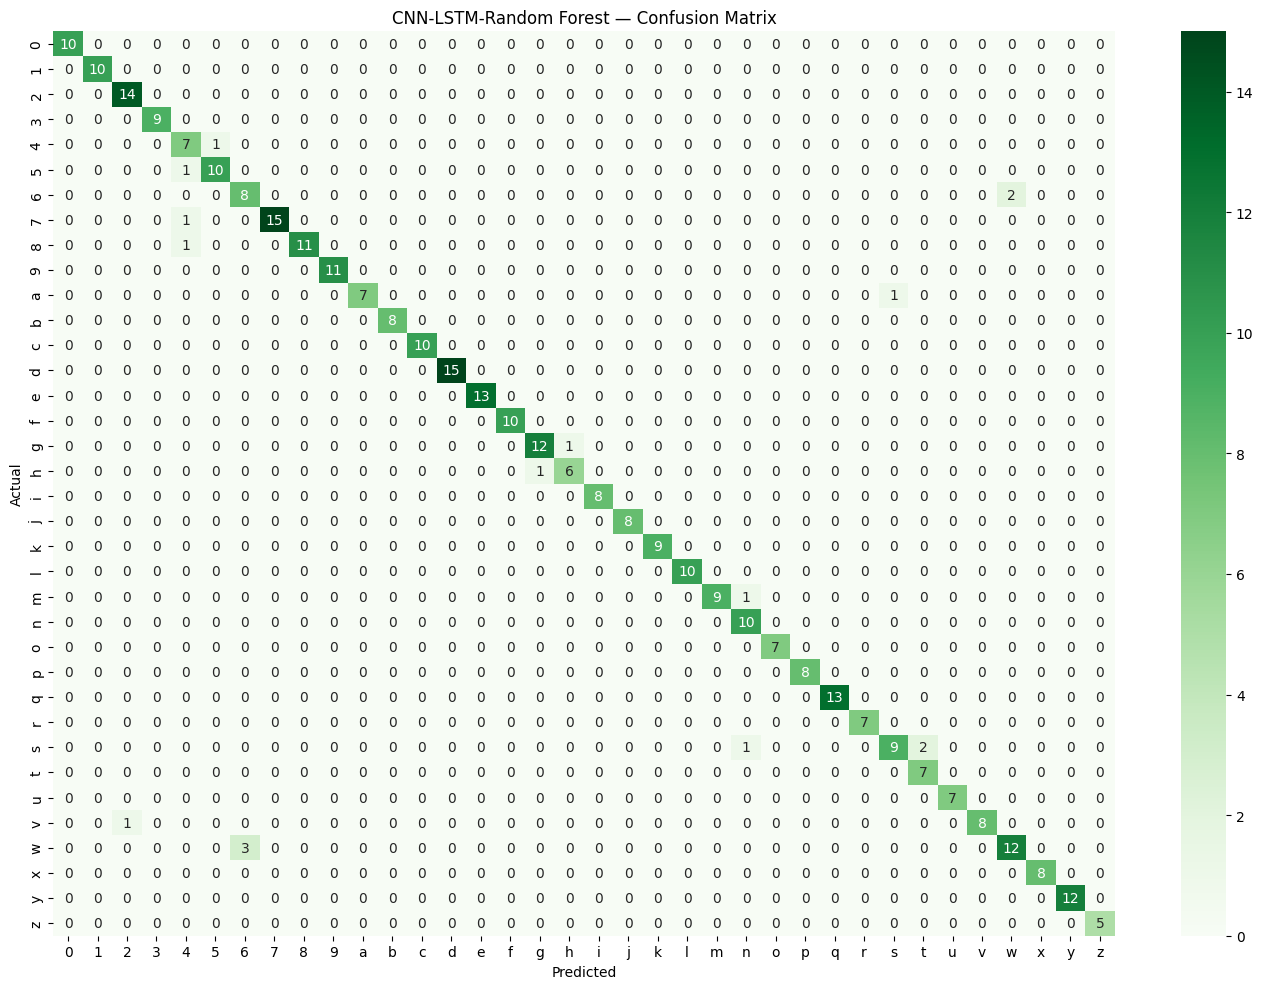

In [23]:
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(confusion_matrix(Y_ste, rf_preds), annot=True, fmt='d',
            cmap='Greens', xticklabels=seq_enc.classes_,
            yticklabels=seq_enc.classes_, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('CNN-LSTM-Random Forest — Confusion Matrix')
plt.tight_layout(); plt.show()


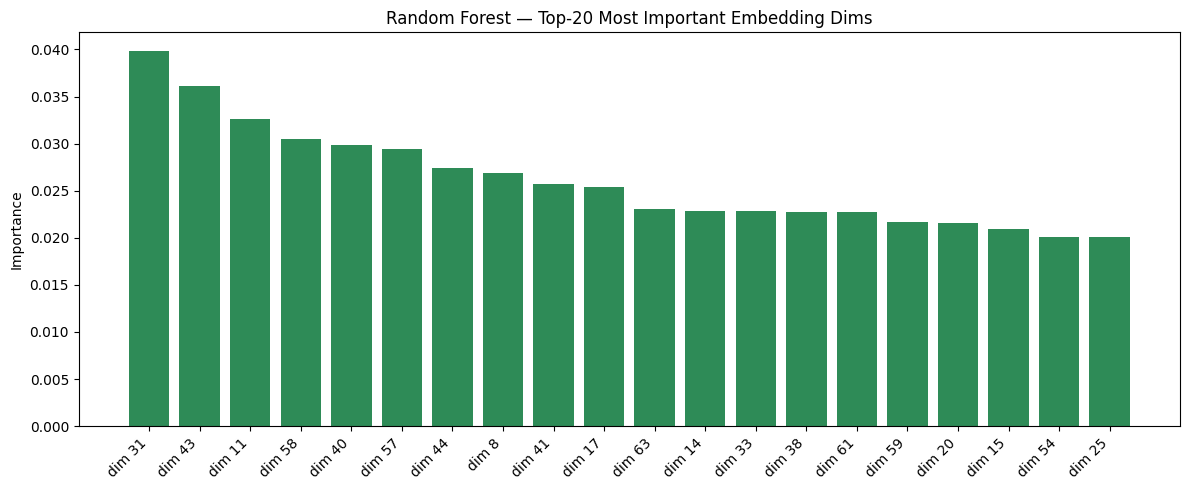

In [24]:
imp     = rf.feature_importances_
top_idx = np.argsort(imp)[::-1][:20]
plt.figure(figsize=(12, 5))
plt.bar(range(20), imp[top_idx], color='seagreen')
plt.xticks(range(20), [f'dim {i}' for i in top_idx], rotation=45, ha='right')
plt.title('Random Forest — Top-20 Most Important Embedding Dims')
plt.ylabel('Importance'); plt.tight_layout(); plt.show()


                   Model  Accuracy  Accuracy (%)
          Standalone CNN  0.037698          3.77
          CNN-LSTM + KNN  0.986111         98.61
CNN-LSTM + Random Forest  0.952778         95.28


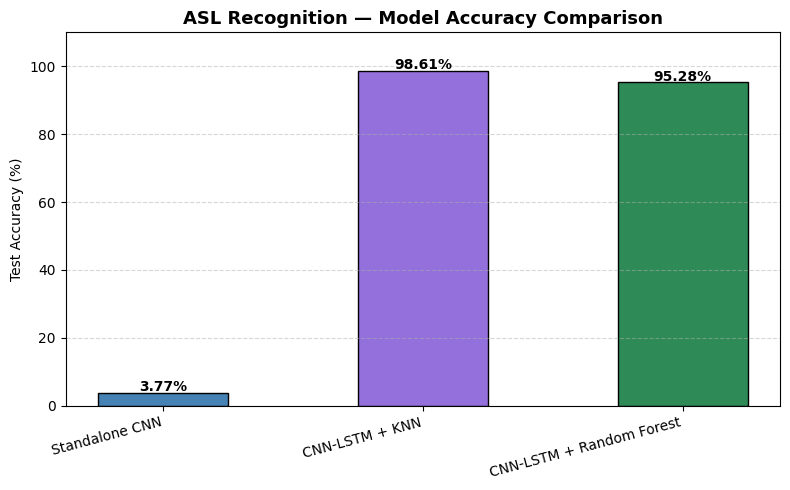

In [25]:
results = pd.DataFrame({
    'Model'   : ['Standalone CNN', 'CNN-LSTM + KNN', 'CNN-LSTM + Random Forest'],
    'Accuracy': [cnn_acc, knn_acc, rf_acc]
})
results['Accuracy (%)'] = (results['Accuracy'] * 100).round(2)
print(results.to_string(index=False))

palette = ['steelblue', 'mediumpurple', 'seagreen']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(results['Model'], results['Accuracy (%)'],
              color=palette, edgecolor='black', width=0.5)
for bar, val in zip(bars, results['Accuracy (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.2f}%', ha='center', fontweight='bold')
ax.set_ylim(0, 110)
ax.set_title('ASL Recognition — Model Accuracy Comparison',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)')
plt.xticks(rotation=15, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()


In [26]:
cnn_model.save('asl_cnn.h5')
with open('asl_label_enc_cnn.pkl', 'wb') as f: pickle.dump(label_enc, f)

feat_mdl.save('asl_cnn_lstm_extractor.h5')
with open('asl_label_enc_seq.pkl', 'wb') as f: pickle.dump(seq_enc, f)

joblib.dump(knn, 'asl_knn.pkl')
joblib.dump(rf,  'asl_rf.pkl')

print('All models and encoders saved.')


All models and encoders saved.
